    menu   sales     ratio  cum_ratio
1     소주  771155  0.275981   0.275981
5     기타  744167  0.266323   0.542304
3   소생막창  465838  0.166714   0.709019
4     맥주  359178  0.128543   0.837562
2    꼬들살  231932  0.083004   0.920566
0  돼지생막창  221958  0.079434   1.000000


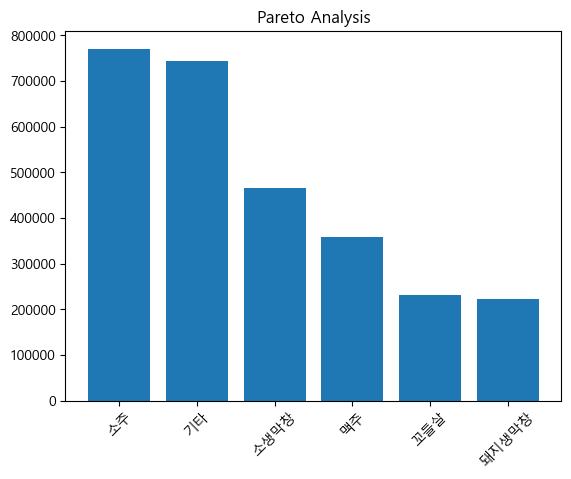

    menu   sales     ratio  cum_ratio  contribution  cum_contribution  \
1     소주  771155  0.275981   0.275981      231346.5          231346.5   
5     기타  744167  0.266323   0.542304      223250.1          454596.6   
3   소생막창  465838  0.166714   0.709019      139751.4          594348.0   
4     맥주  359178  0.128543   0.837562      107753.4          702101.4   
2    꼬들살  231932  0.083004   0.920566       69579.6          771681.0   
0  돼지생막창  221958  0.079434   1.000000       66587.4          838268.4   

        ABC ABC_class  
1  0.275981         A  
5  0.542304         A  
3  0.709019         A  
4  0.837562         B  
2  0.920566         B  
0  1.000000         C  
BEP: 14649180
이벤트로 인한 이익 변화: -474560


In [4]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 한글폰트
plt.rcParams['axes.unicode_minus'] = False
import pandas as pd
import numpy as np


# ---------------------------
# 1. 샘플 데이터 생성
# ---------------------------
np.random.seed(42)

menu = ['돼지생막창', '소주', '꼬들살', '소생막창', '맥주', '기타']
sales = np.random.randint(100000, 1000000, size=len(menu))

df = pd.DataFrame({
    'menu': menu,
    'sales': sales
})

# ---------------------------
# 2. 파레토 분석
# ---------------------------
pareto = df.sort_values(by='sales', ascending=False)
pareto['ratio'] = pareto['sales'] / pareto['sales'].sum()
pareto['cum_ratio'] = pareto['ratio'].cumsum()

print(pareto)

plt.figure()
plt.bar(pareto['menu'], pareto['sales'])
plt.xticks(rotation=45)
plt.title("Pareto Analysis")
plt.show()

# ---------------------------
# 3. 공헌이익 기반 ABC 분석
# ---------------------------
pareto['contribution'] = pareto['sales'] * 0.3  # 가정
pareto['cum_contribution'] = pareto['contribution'].cumsum()
total = pareto['contribution'].sum()

def abc_class(x):
    if x <= 0.8:
        return 'A'
    elif x <= 0.95:
        return 'B'
    else:
        return 'C'

pareto['ABC'] = pareto['cum_contribution'] / total
pareto['ABC_class'] = pareto['ABC'].apply(abc_class)

print(pareto)

# ---------------------------
# 4. 손익분기점 계산
# ---------------------------
fixed_cost = 8936000
contribution_margin_ratio = 0.61

bep = fixed_cost / contribution_margin_ratio
print(f"BEP: {int(bep)}")

# ---------------------------
# 5. 이벤트 수익성 비교
# ---------------------------
normal_profit = 3819800
event_profit = 3345240

print("이벤트로 인한 이익 변화:", event_profit - normal_profit)